ejercicio 1

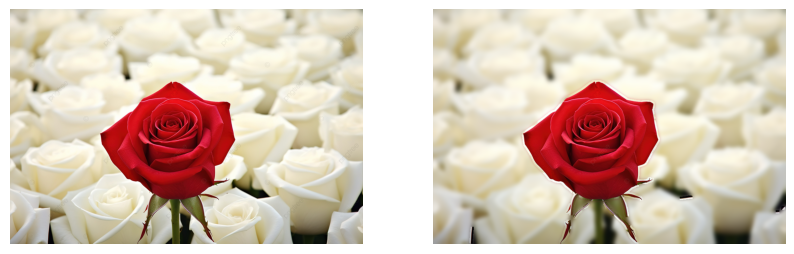

In [5]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img_rosa = cv2.imread('rosa.png')
img_rgb = cv2.cvtColor(img_rosa, cv2.COLOR_BGR2RGB)

hsv = cv2.cvtColor(img_rosa, cv2.COLOR_BGR2HSV)

rango_bajo1 = np.array([0, 100, 50])
rango_alto1 = np.array([10, 255, 255])
rango_bajo2 = np.array([160, 100, 50])
rango_alto2 = np.array([179, 255, 255])

mask1 = cv2.inRange(hsv, rango_bajo1, rango_alto1)
mask2 = cv2.inRange(hsv, rango_bajo2, rango_alto2)
mascara_rosa = cv2.bitwise_or(mask1, mask2)

kernel = np.ones((5, 5), np.uint8)
mascara_rosa = cv2.dilate(mascara_rosa, kernel, iterations=2)

fondo_difuminado = cv2.GaussianBlur(img_rgb, (35, 35), 0)

mascara_3d = np.stack([mascara_rosa > 0] * 3, axis=-1)
resultado_final = np.where(mascara_3d, img_rgb, fondo_difuminado)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(img_rgb)
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(resultado_final)
plt.axis('off')
plt.show()

ejercicio 2

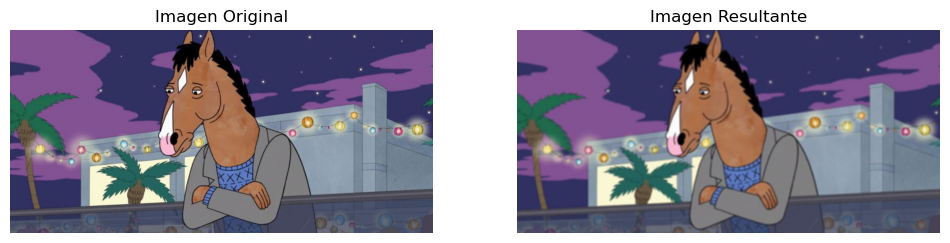

In [10]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img_bojack = cv2.imread('imagen1.jpg')
img_bojack_rgb = cv2.cvtColor(img_bojack, cv2.COLOR_BGR2RGB)

k = 4
kernel_promediado = np.ones((k, k), np.float32) / (k * k)

resultado_blur = cv2.filter2D(img_bojack_rgb, -1, kernel_promediado)

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(img_bojack_rgb)
plt.title('Imagen Original')
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(resultado_blur)
plt.title('Imagen Resultante')
plt.axis('off')
plt.show()

Ejericicio 3

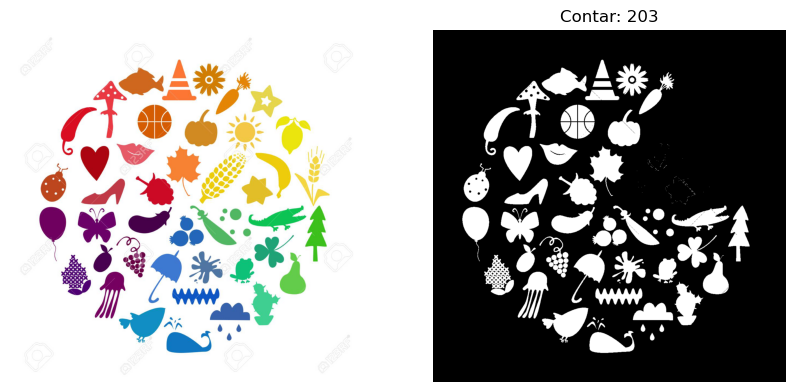

Contar: 203


In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img_elementos = cv2.imread('Elementos.jpg')
img_rgb = cv2.cvtColor(img_elementos, cv2.COLOR_BGR2RGB)
gray = cv2.cvtColor(img_elementos, cv2.COLOR_BGR2GRAY)

_, binarizada = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

num_l, _ = cv2.connectedComponents(binarizada)
num_elementos = num_l

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(img_rgb)
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(binarizada, cmap='gray')
plt.title(f'Contar: {num_elementos}')
plt.axis('off')
plt.show()

print(f"Contar: {num_elementos}")

ejercicio 5

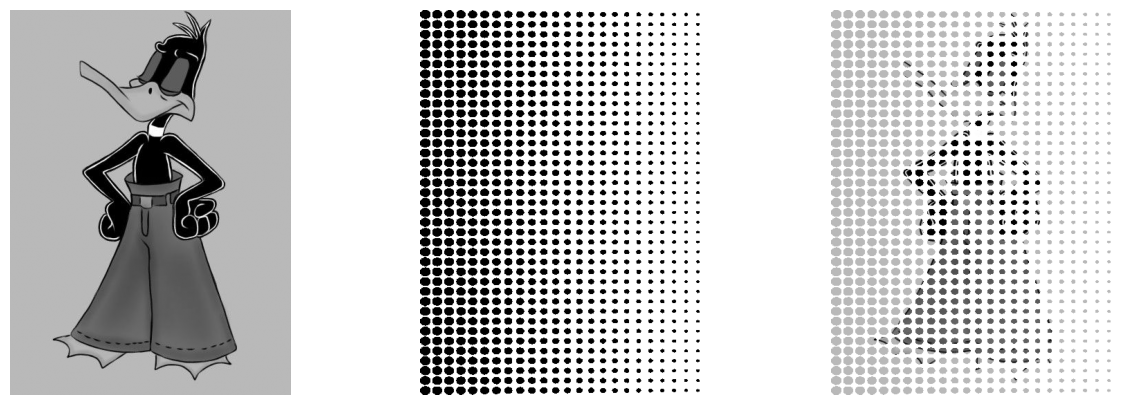

In [11]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

pato = cv2.imread('pato.jpg', 0)
puntos = cv2.resize(cv2.imread('puntos.png', 0), (pato.shape[1], pato.shape[0]))

_, mask = cv2.threshold(puntos, 127, 255, cv2.THRESH_BINARY)
resultado = np.where(mask == 0, pato, 255)

plt.figure(figsize=(15, 5))
for i, img in enumerate([pato, mask, resultado], 1):
    plt.subplot(1, 3, i)
    plt.imshow(img, cmap='gray')
    plt.axis('off')
plt.show()